# 二、数据获取与处理

本部分使用Python完成A股数据的获取、清洗与初步分析。

## 2.1 数据获取

使用tushare模块获取A股日频数据。本次选取贵州茅台 (600519.SH), 比亚迪 (002594.SZ), 中国平安 (601318.SH), 宁德时代 (300750.SZ)四只股票，时间范围为2023年1月1日至今。

In [1]:
# 导入必要的库
import tushare as ts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号
warnings.filterwarnings('ignore')

# 设置Tushare Token
my_token = '229e2c478deaef0ccf3030b42121cc7b5ba066dd3c9789b4835c943d'
ts.set_token(my_token)
pro = ts.pro_api()

print("库导入成功，Tushare初始化完成！")

库导入成功，Tushare初始化完成！


In [2]:
# 定义获取数据的函数
def get_stock_data(ts_code, start_date, end_date):
    """
    使用Tushare获取股票日线数据
    """
    try:
        # 获取日线行情
        # 包含字段：ts_code(代码), trade_date(交易日期), open(开盘价), high(最高价), low(最低价), close(收盘价), 
        # pre_close(昨收价), change(涨跌额), pct_chg(涨跌幅), vol(成交量), amount(成交额)
        df = pro.daily(ts_code=ts_code, start_date=start_date, end_date=end_date)
        
        if df is None or df.empty:
            print(f"Warning: {ts_code} 返回数据为空")
            return None
            
        # tushare返回的数据是按日期倒序的，通常我们需要升序
        df = df.sort_values('trade_date').reset_index(drop=True)
        return df
    except Exception as e:
        print(f"获取 {ts_code} 数据时发生错误: {e}")
        return None

# 获取多只股票数据
# 贵州茅台 (600519.SH), 比亚迪 (002594.SZ), 中国平安 (601318.SH), 宁德时代 (300750.SZ)
stock_list = {
    "贵州茅台": "600519.SH",
    "比亚迪": "002594.SZ",
    "中国平安": "601318.SH",
    "宁德时代": "300750.SZ"
}

start_date = "20230101"
end_date = "20251231"

data_dict = {}

# 遍历获取数据
for name, code in stock_list.items():
    print(f"正在获取 {name} ({code}) ...")
    df = get_stock_data(code, start_date, end_date)
    if df is not None:
        data_dict[name] = df
        print(f"  成功! 数据形状: {df.shape}")
    else:
        print(f"  失败!")

# 将常用股票赋值给全局变量，方便后续单独调用（兼容旧代码）
if "贵州茅台" in data_dict:
    df_maotai = data_dict["贵州茅台"]
if "比亚迪" in data_dict:
    df_byd = data_dict["比亚迪"]

# 预览数据
print("\n数据获取完成。")
print("已获取股票:", list(data_dict.keys()))
if "贵州茅台" in data_dict:
    print("\n贵州茅台前5行数据:")
    print(data_dict["贵州茅台"].head())

正在获取 贵州茅台 (600519.SH) ...
  成功! 数据形状: (727, 11)
正在获取 比亚迪 (002594.SZ) ...
  成功! 数据形状: (727, 11)
正在获取 中国平安 (601318.SH) ...
  成功! 数据形状: (727, 11)
正在获取 宁德时代 (300750.SZ) ...
  成功! 数据形状: (727, 11)

数据获取完成。
已获取股票: ['贵州茅台', '比亚迪', '中国平安', '宁德时代']

贵州茅台前5行数据:
     ts_code trade_date     open     high      low    close  pre_close  \
0  600519.SH   20230103  1731.20  1738.43  1706.01  1730.01    1727.00   
1  600519.SH   20230104  1730.00  1738.70  1716.00  1725.01    1730.01   
2  600519.SH   20230105  1737.00  1801.00  1733.00  1801.00    1725.01   
3  600519.SH   20230106  1806.12  1811.90  1787.00  1803.77    1801.00   
4  600519.SH   20230109  1835.00  1849.98  1807.82  1841.20    1803.77   

   change  pct_chg       vol       amount  
0    3.01   0.1743  26033.80  4487760.231  
1   -5.00  -0.2890  20415.75  3523582.306  
2   75.99   4.4052  47942.85  8541587.089  
3    2.77   0.1538  24903.75  4480838.898  
4   37.43   2.0751  30977.23  5684181.147  


In [3]:
# 查看数据字典中的数据
print("已获取的股票数据列表:", list(data_dict.keys()))

# 查看比亚迪数据（如果获取成功）
if "比亚迪" in data_dict:
    print("\n比亚迪数据预览:")
    print(data_dict["比亚迪"].head())
    print("数据形状:", data_dict["比亚迪"].shape)

# 查看中国平安数据（如果获取成功）
if "中国平安" in data_dict:
    print("\n中国平安数据预览:")
    print(data_dict["中国平安"].head())
    print("数据形状:", data_dict["中国平安"].shape)

# 查看宁德时代数据（如果获取成功）
if "宁德时代" in data_dict:
    print("\n宁德时代数据预览:")
    print(data_dict["宁德时代"].head())
    print("数据形状:", data_dict["宁德时代"].shape)

已获取的股票数据列表: ['贵州茅台', '比亚迪', '中国平安', '宁德时代']

比亚迪数据预览:
     ts_code trade_date    open    high     low   close  pre_close  change  \
0  002594.SZ   20230103  256.41  261.92  250.00  260.48     256.97    3.51   
1  002594.SZ   20230104  260.00  260.48  256.50  259.10     260.48   -1.38   
2  002594.SZ   20230105  262.52  267.59  261.06  265.08     259.10    5.98   
3  002594.SZ   20230106  267.91  271.20  265.10  266.20     265.08    1.12   
4  002594.SZ   20230109  268.00  268.00  262.29  263.38     266.20   -2.82   

   pct_chg        vol       amount  
0   1.3659  121374.30  3108609.041  
1  -0.5298   72674.59  1881537.612  
2   2.3080  118936.00  3143084.205  
3   0.4225  138855.23  3726792.589  
4  -1.0594  114168.82  3020383.480  
数据形状: (727, 11)

中国平安数据预览:
     ts_code trade_date   open   high    low  close  pre_close  change  \
0  601318.SH   20230103  46.59  47.26  46.06  47.15      47.00    0.15   
1  601318.SH   20230104  47.30  48.63  47.30  48.53      47.15    1.38   
2  601

In [4]:
# 查看数据基本信息
print("=" * 50)
print("贵州茅台数据信息：")
print("=" * 50)
df_maotai.info()

贵州茅台数据信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 727 entries, 0 to 726
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ts_code     727 non-null    object 
 1   trade_date  727 non-null    object 
 2   open        727 non-null    float64
 3   high        727 non-null    float64
 4   low         727 non-null    float64
 5   close       727 non-null    float64
 6   pre_close   727 non-null    float64
 7   change      727 non-null    float64
 8   pct_chg     727 non-null    float64
 9   vol         727 non-null    float64
 10  amount      727 non-null    float64
dtypes: float64(9), object(2)
memory usage: 62.6+ KB


In [5]:
# 查看数据尾部
print("贵州茅台最新10条数据：")
df_maotai.tail(10)

贵州茅台最新10条数据：


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
717,600519.SH,20251218,1433.50,1438.88,1426.11,1431.00,1433.10,-2.10,-0.1465,17829.95,2551177.659
718,600519.SH,20251219,1410.00,1412.45,1401.01,1410.00,1407.04,2.96,0.2104,26508.68,3733028.357
719,600519.SH,20251222,1410.00,1414.14,1406.58,1408.26,1410.00,-1.74,-0.1234,20425.65,2881636.856
720,600519.SH,20251223,1408.26,1412.93,1397.19,1407.86,1408.26,-0.40,-0.0284,24506.81,3445377.032
721,600519.SH,20251224,1404.99,1406.36,1400.00,1400.90,1407.86,-6.96,-0.4944,25186.69,3533253.565
722,600519.SH,20251225,1405.00,1419.48,1401.38,1414.17,1400.90,13.27,0.9472,23386.21,3299572.096
723,600519.SH,20251226,1414.17,1419.14,1410.00,1414.13,1414.17,-0.04,-0.0028,17802.99,2520605.635
724,600519.SH,20251229,1414.13,1414.13,1401.00,1402.00,1414.13,-12.13,-0.8578,26308.10,3694660.107
725,600519.SH,20251230,1401.00,1401.90,1386.00,1389.72,1402.00,-12.28,-0.8759,33791.94,4702489.813
726,600519.SH,20251231,1390.00,1394.00,1377.17,1377.18,1389.72,-12.54,-0.9023,34765.63,4799456.452


## 2.2 数据清洗与指标计算

对获取的数据进行清洗处理并计算关键指标：
1. **数据清洗**：重命名列名为标准英文格式（date, symbol, close, volume等），将日期转换为时间戳索引，处理缺失值与重复值。
2. **指标计算**：
   - 移动平均线：MA5, MA20, MA60
   - 收益率：日收益率 (daily_return), 累计收益率 (cum_return)
   - 波动率：20日滚动波动率 (volatility_20)
   - 其他：RSI指标, 布林带 (BOLL)

In [6]:
def process_stock_data(df, stock_name):
    """
    股票数据清洗与特征工程函数
    1. 处理缺失值
    2. 格式转换（日期、列名）
    3. 计算技术指标（均线、收益率等）
    """
    if df is None or df.empty:
        print(f"{stock_name}: 数据为空，跳过处理")
        return None

    # 复制数据
    df_clean = df.copy()
    
    print(f"{'='*50}")
    print(f"{stock_name} 数据处理开始")
    
    # --- 1. 列名重命名 ---
    # 建立映射关系 Tushare -> 标准字段
    rename_dict = {
        'trade_date': 'date',
        'ts_code': 'symbol',
        'vol': 'volume',
        'amount': 'turnover'
    }
    # 仅重命名存在的列
    df_clean.rename(columns=rename_dict, inplace=True)
    
    # --- 2. 日期格式处理与索引设置 ---
    if 'date' in df_clean.columns:
        df_clean['date'] = pd.to_datetime(df_clean['date'].astype(str))
        df_clean.set_index('date', inplace=True)
        df_clean.sort_index(inplace=True) # 确保按日期升序
    
    # --- 3. 缺失值与重复值处理 ---
    # 删除完全重复的行
    df_clean.drop_duplicates(inplace=True)
    # 处理缺失值（前向填充）
    if df_clean.isnull().sum().sum() > 0:
        df_clean.ffill(inplace=True).bfill(inplace=True)
    
    # --- 4. 计算新增字段 (技术指标) ---
    # 价格均线
    df_clean['MA5'] = df_clean['close'].rolling(window=5).mean()
    df_clean['MA20'] = df_clean['close'].rolling(window=20).mean()
    df_clean['MA60'] = df_clean['close'].rolling(window=60).mean()
    
    # 成交量均线 (新增)
    df_clean['volume_MA5'] = df_clean['volume'].rolling(window=5).mean()
    df_clean['volume_MA20'] = df_clean['volume'].rolling(window=20).mean()

    # 日收益率 (%)
    df_clean['daily_return'] = df_clean['close'].pct_change() * 100
    
    # 累计收益率 (%)
    df_clean['cum_return'] = (1 + df_clean['daily_return']/100).cumprod() - 1
    df_clean['cum_return'] *= 100

    # 波动率 (20日滚动)
    df_clean['volatility_20'] = df_clean['daily_return'].rolling(window=20).std()
    
    # RSI相对强弱指标 (14日)
    delta = df_clean['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df_clean['RSI'] = 100 - (100 / (1 + rs))
    
    # 布林带
    df_clean['BOLL_MID'] = df_clean['close'].rolling(window=20).mean()
    df_clean['BOLL_STD'] = df_clean['close'].rolling(window=20).std()
    df_clean['BOLL_UP'] = df_clean['BOLL_MID'] + 2 * df_clean['BOLL_STD']
    df_clean['BOLL_DOWN'] = df_clean['BOLL_MID'] - 2 * df_clean['BOLL_STD']

    print(f"处理完成! 最终形状: {df_clean.shape}")
    print(f"新增指标: MA5...MA60, volume_MA5, daily_return, RSI, BOLL...")
    
    return df_clean

# 批量处理所有股票数据
data_final_dict = {}

for name, df in data_dict.items():
    processed_df = process_stock_data(df, name)
    if processed_df is not None:
        data_final_dict[name] = processed_df

# 更新全局变量供后续分析使用
if "贵州茅台" in data_final_dict:
    df_maotai_final = data_final_dict["贵州茅台"]
if "比亚迪" in data_final_dict:
    df_byd_final = data_final_dict["比亚迪"]

print(f"\n{'='*50}")
if "贵州茅台" in data_final_dict:
    print("贵州茅台 数据预览 (含指标):")
    print(df_maotai_final[['close', 'MA5', 'volume_MA5', 'daily_return']].tail())

贵州茅台 数据处理开始
处理完成! 最终形状: (727, 23)
新增指标: MA5...MA60, volume_MA5, daily_return, RSI, BOLL...
比亚迪 数据处理开始
处理完成! 最终形状: (727, 23)
新增指标: MA5...MA60, volume_MA5, daily_return, RSI, BOLL...
中国平安 数据处理开始
处理完成! 最终形状: (727, 23)
新增指标: MA5...MA60, volume_MA5, daily_return, RSI, BOLL...
宁德时代 数据处理开始
处理完成! 最终形状: (727, 23)
新增指标: MA5...MA60, volume_MA5, daily_return, RSI, BOLL...

贵州茅台 数据预览 (含指标):
              close       MA5  volume_MA5  daily_return
date                                                   
2025-12-25  1414.17  1408.238   24002.808      0.947248
2025-12-26  1414.13  1409.064   22261.670     -0.002829
2025-12-29  1402.00  1407.812   23438.160     -0.857771
2025-12-30  1389.72  1404.184   25295.186     -0.875892
2025-12-31  1377.18  1399.440   27210.974     -0.902340


In [7]:
# 查看最终数据结构
print("贵州茅台最终数据结构：")
print(f"数据形状: {df_maotai_final.shape}")
print(f"\n列名列表:")
for i, col in enumerate(df_maotai_final.columns):
    print(f"  {i+1}. {col}")

贵州茅台最终数据结构：
数据形状: (727, 23)

列名列表:
  1. symbol
  2. open
  3. high
  4. low
  5. close
  6. pre_close
  7. change
  8. pct_chg
  9. volume
  10. turnover
  11. MA5
  12. MA20
  13. MA60
  14. volume_MA5
  15. volume_MA20
  16. daily_return
  17. cum_return
  18. volatility_20
  19. RSI
  20. BOLL_MID
  21. BOLL_STD
  22. BOLL_UP
  23. BOLL_DOWN


In [8]:
# 查看添加指标后的数据
print("贵州茅台数据预览（含技术指标）：")
df_maotai_final[['close', 'MA5', 'MA20', 'daily_return', 'RSI', 'BOLL_UP', 'BOLL_DOWN']].tail(10)

贵州茅台数据预览（含技术指标）：


,close,MA5,MA20,daily_return,RSI,BOLL_UP,BOLL_DOWN
date,,,,,,,
2025-12-18,1431.00,1426.550,1432.2045,-0.146535,40.601504,1466.681284,1397.727716
2025-12-19,1410.00,1424.420,1429.3745,-1.467505,34.456806,1461.149672,1397.599328
2025-12-22,1408.26,1420.872,1427.1875,-0.123404,37.603785,1458.422238,1395.952762
2025-12-23,1407.86,1418.044,1425.3480,-0.028404,39.931741,1456.585899,1394.110101
2025-12-24,1400.90,1411.604,1422.9355,-0.494367,39.247111,1453.884852,1391.986148
2025-12-25,1414.17,1408.238,1421.2790,0.947248,43.086592,1450.218762,1392.339238
2025-12-26,1414.13,1409.064,1419.4605,-0.002829,48.010894,1445.045340,1393.875660
2025-12-29,1402.00,1407.812,1417.1605,-0.857771,50.506497,1440.073793,1394.247207
2025-12-30,1389.72,1404.184,1414.8450,-0.875892,43.956755,1439.052578,1390.637422


## 2.3 数据初步分析

对清洗后的数据进行统计分析，包括：
1. 描述性统计
2. 日收益率分布分析
3. 成交量分布分析
4. 价格走势可视化

### 2.3.1 描述性统计

In [9]:
# 贵州茅台描述性统计
print("=" * 60)
print("贵州茅台 描述性统计")
print("=" * 60)
df_maotai_final[['open', 'high', 'low', 'close', 'volume', 'daily_return']].describe()

贵州茅台 描述性统计


,open,high,low,close,volume,daily_return
count,727.000000,727.000000,727.000000,727.000000,727.000000,726.000000
mean,1605.418336,1619.294952,1591.517538,1604.480523,29930.506231,-0.021728
std,149.396927,149.547042,146.537269,148.202458,15626.109420,1.399126
min,1261.500000,1273.900000,1245.830000,1261.000000,10321.040000,-7.420197
25%,1465.075000,1478.780000,1453.500000,1465.105000,20292.080000,-0.718592
50%,1596.000000,1612.800000,1575.050000,1591.180000,26485.150000,-0.095130
75%,1728.995000,1738.565000,1711.415000,1724.325000,34902.575000,0.517517
max,1914.000000,1935.000000,1895.000000,1912.900000,194709.470000,9.292352


In [10]:
# 比亚迪描述性统计
print("=" * 60)
print("比亚迪 描述性统计")
print("=" * 60)
df_byd_final[['open', 'high', 'low', 'close', 'volume', 'daily_return']].describe()

比亚迪 描述性统计


,open,high,low,close,volume,daily_return
count,727.000000,727.000000,727.000000,727.000000,7.270000e+02,726.000000
mean,242.696011,245.868913,239.638707,242.691596,1.781535e+05,-0.054851
std,75.408062,76.479257,74.212432,75.341121,1.589854e+05,3.192707
min,92.490000,94.390000,91.700000,92.700000,4.138033e+04,-66.937685
25%,208.860000,211.445000,206.285000,208.470000,9.136011e+04,-1.063771
50%,250.000000,253.000000,247.100000,249.980000,1.216262e+05,-0.140755
75%,281.575000,285.330000,278.680000,281.915000,1.913842e+05,1.044560
max,401.810000,416.980000,398.130000,405.000000,1.329867e+06,10.000000


In [11]:
# 计算关键统计指标
def calculate_statistics(df, stock_name):
    """
    计算关键统计指标
    """
    print(f"\n{'='*50}")
    print(f"{stock_name} 关键统计指标")
    print(f"{'='*50}")
    
    # 剔除NaN值计算
    returns = df['daily_return'].dropna()
    
    # 基本统计
    print(f"\n【价格统计】")
    print(f"  期初价格: {df['close'].iloc[0]:.2f} 元")
    print(f"  期末价格: {df['close'].iloc[-1]:.2f} 元")
    print(f"  最高价格: {df['high'].max():.2f} 元")
    print(f"  最低价格: {df['low'].min():.2f} 元")
    print(f"  价格均值: {df['close'].mean():.2f} 元")
    
    # 收益统计
    print(f"\n【收益统计】")
    total_return = (df['close'].iloc[-1] / df['close'].iloc[0] - 1) * 100
    print(f"  区间总收益率: {total_return:.2f}%")
    print(f"  日均收益率: {returns.mean():.4f}%")
    print(f"  日收益率标准差: {returns.std():.4f}%")
    print(f"  最大单日涨幅: {returns.max():.2f}%")
    print(f"  最大单日跌幅: {returns.min():.2f}%")
    
    # 年化指标（假设一年250个交易日）
    annual_return = returns.mean() * 250
    annual_volatility = returns.std() * np.sqrt(250)
    sharpe_ratio = annual_return / annual_volatility if annual_volatility != 0 else 0
    
    print(f"\n【年化指标】")
    print(f"  年化收益率: {annual_return:.2f}%")
    print(f"  年化波动率: {annual_volatility:.2f}%")
    print(f"  夏普比率: {sharpe_ratio:.4f}")
    
    # 成交量统计
    print(f"\n【成交量统计】")
    print(f"  日均成交量: {df['volume'].mean()/10000:.2f} 万手")
    print(f"  最大成交量: {df['volume'].max()/10000:.2f} 万手")
    print(f"  最小成交量: {df['volume'].min()/10000:.2f} 万手")
    
    # 涨跌统计
    up_days = (returns > 0).sum()
    down_days = (returns < 0).sum()
    flat_days = (returns == 0).sum()
    total_days = len(returns)
    
    print(f"\n【涨跌统计】")
    print(f"  总交易日: {total_days} 天")
    print(f"  上涨天数: {up_days} 天 ({up_days/total_days*100:.1f}%)")
    print(f"  下跌天数: {down_days} 天 ({down_days/total_days*100:.1f}%)")
    print(f"  平盘天数: {flat_days} 天 ({flat_days/total_days*100:.1f}%)")

# 计算两只股票的统计指标
calculate_statistics(df_maotai_final, "贵州茅台")
calculate_statistics(df_byd_final, "比亚迪")


贵州茅台 关键统计指标

【价格统计】
  期初价格: 1730.01 元
  期末价格: 1377.18 元
  最高价格: 1935.00 元
  最低价格: 1245.83 元
  价格均值: 1604.48 元

【收益统计】
  区间总收益率: -20.39%
  日均收益率: -0.0217%
  日收益率标准差: 1.3991%
  最大单日涨幅: 9.29%
  最大单日跌幅: -7.42%

【年化指标】
  年化收益率: -5.43%
  年化波动率: 22.12%
  夏普比率: -0.2455

【成交量统计】
  日均成交量: 2.99 万手
  最大成交量: 19.47 万手
  最小成交量: 1.03 万手

【涨跌统计】
  总交易日: 726 天
  上涨天数: 326 天 (44.9%)
  下跌天数: 397 天 (54.7%)
  平盘天数: 3 天 (0.4%)

比亚迪 关键统计指标

【价格统计】
  期初价格: 260.48 元
  期末价格: 97.72 元
  最高价格: 416.98 元
  最低价格: 91.70 元
  价格均值: 242.69 元

【收益统计】
  区间总收益率: -62.48%
  日均收益率: -0.0549%
  日收益率标准差: 3.1927%
  最大单日涨幅: 10.00%
  最大单日跌幅: -66.94%

【年化指标】
  年化收益率: -13.71%
  年化波动率: 50.48%
  夏普比率: -0.2716

【成交量统计】
  日均成交量: 17.82 万手
  最大成交量: 132.99 万手
  最小成交量: 4.14 万手

【涨跌统计】
  总交易日: 726 天
  上涨天数: 336 天 (46.3%)
  下跌天数: 390 天 (53.7%)
  平盘天数: 0 天 (0.0%)


### 2.3.2 日收益率分布分析

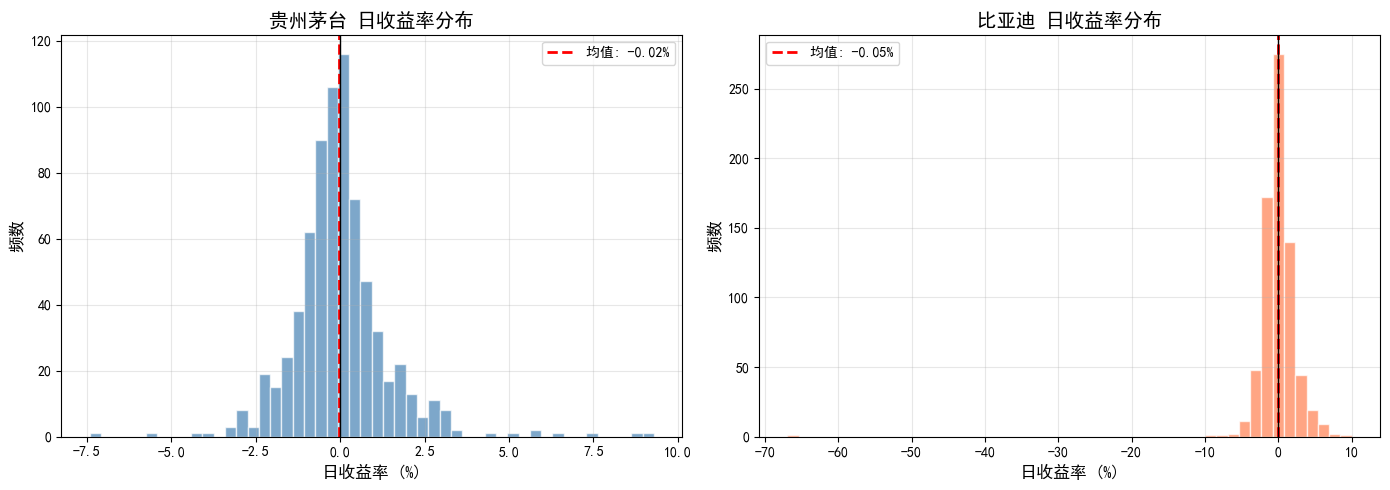

图片已保存: 题目一_output/daily_return_distribution.png


In [12]:
# 绘制日收益率分布直方图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 贵州茅台
ax1 = axes[0]
returns_maotai = df_maotai_final['daily_return'].dropna()
ax1.hist(returns_maotai, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
ax1.axvline(returns_maotai.mean(), color='red', linestyle='--', linewidth=2, label=f'均值: {returns_maotai.mean():.2f}%')
ax1.axvline(0, color='black', linestyle='-', linewidth=1)
ax1.set_xlabel('日收益率 (%)', fontsize=12)
ax1.set_ylabel('频数', fontsize=12)
ax1.set_title('贵州茅台 日收益率分布', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 比亚迪
ax2 = axes[1]
returns_byd = df_byd_final['daily_return'].dropna()
ax2.hist(returns_byd, bins=50, color='coral', edgecolor='white', alpha=0.7)
ax2.axvline(returns_byd.mean(), color='red', linestyle='--', linewidth=2, label=f'均值: {returns_byd.mean():.2f}%')
ax2.axvline(0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('日收益率 (%)', fontsize=12)
ax2.set_ylabel('频数', fontsize=12)
ax2.set_title('比亚迪 日收益率分布', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('题目一_output/daily_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("图片已保存: 题目一_output/daily_return_distribution.png")

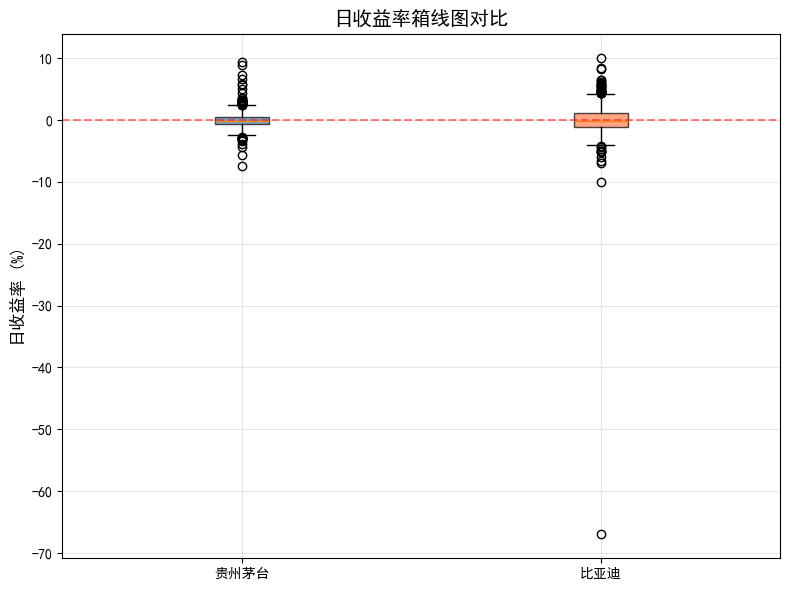

图片已保存: 题目一_output/return_boxplot.png


In [13]:
# 收益率箱线图对比
fig, ax = plt.subplots(figsize=(8, 6))

data_to_plot = [returns_maotai, returns_byd]
bp = ax.boxplot(data_to_plot, labels=['贵州茅台', '比亚迪'], patch_artist=True)

# 设置颜色
colors = ['steelblue', 'coral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('日收益率 (%)', fontsize=12)
ax.set_title('日收益率箱线图对比', fontsize=14)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('题目一_output/return_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print("图片已保存: 题目一_output/return_boxplot.png")

### 2.3.3 成交量分布分析

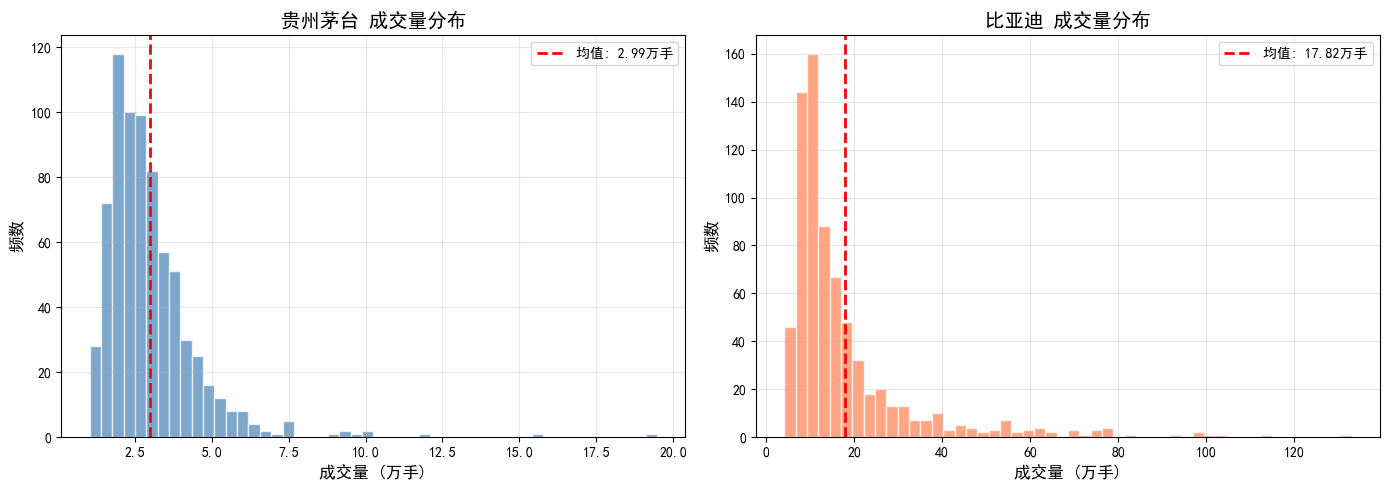

图片已保存: volume_distribution.png


In [14]:
# 绘制成交量分布直方图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 贵州茅台
ax1 = axes[0]
volume_maotai = df_maotai_final['volume'] / 10000  # 转换为万手
ax1.hist(volume_maotai, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
ax1.axvline(volume_maotai.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'均值: {volume_maotai.mean():.2f}万手')
ax1.set_xlabel('成交量 (万手)', fontsize=12)
ax1.set_ylabel('频数', fontsize=12)
ax1.set_title('贵州茅台 成交量分布', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 比亚迪
ax2 = axes[1]
volume_byd = df_byd_final['volume'] / 10000  # 转换为万手
ax2.hist(volume_byd, bins=50, color='coral', edgecolor='white', alpha=0.7)
ax2.axvline(volume_byd.mean(), color='red', linestyle='--', linewidth=2,
            label=f'均值: {volume_byd.mean():.2f}万手')
ax2.set_xlabel('成交量 (万手)', fontsize=12)
ax2.set_ylabel('频数', fontsize=12)
ax2.set_title('比亚迪 成交量分布', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('题目一_output/volume_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("图片已保存: volume_distribution.png")

### 2.3.4 价格走势与均线可视化

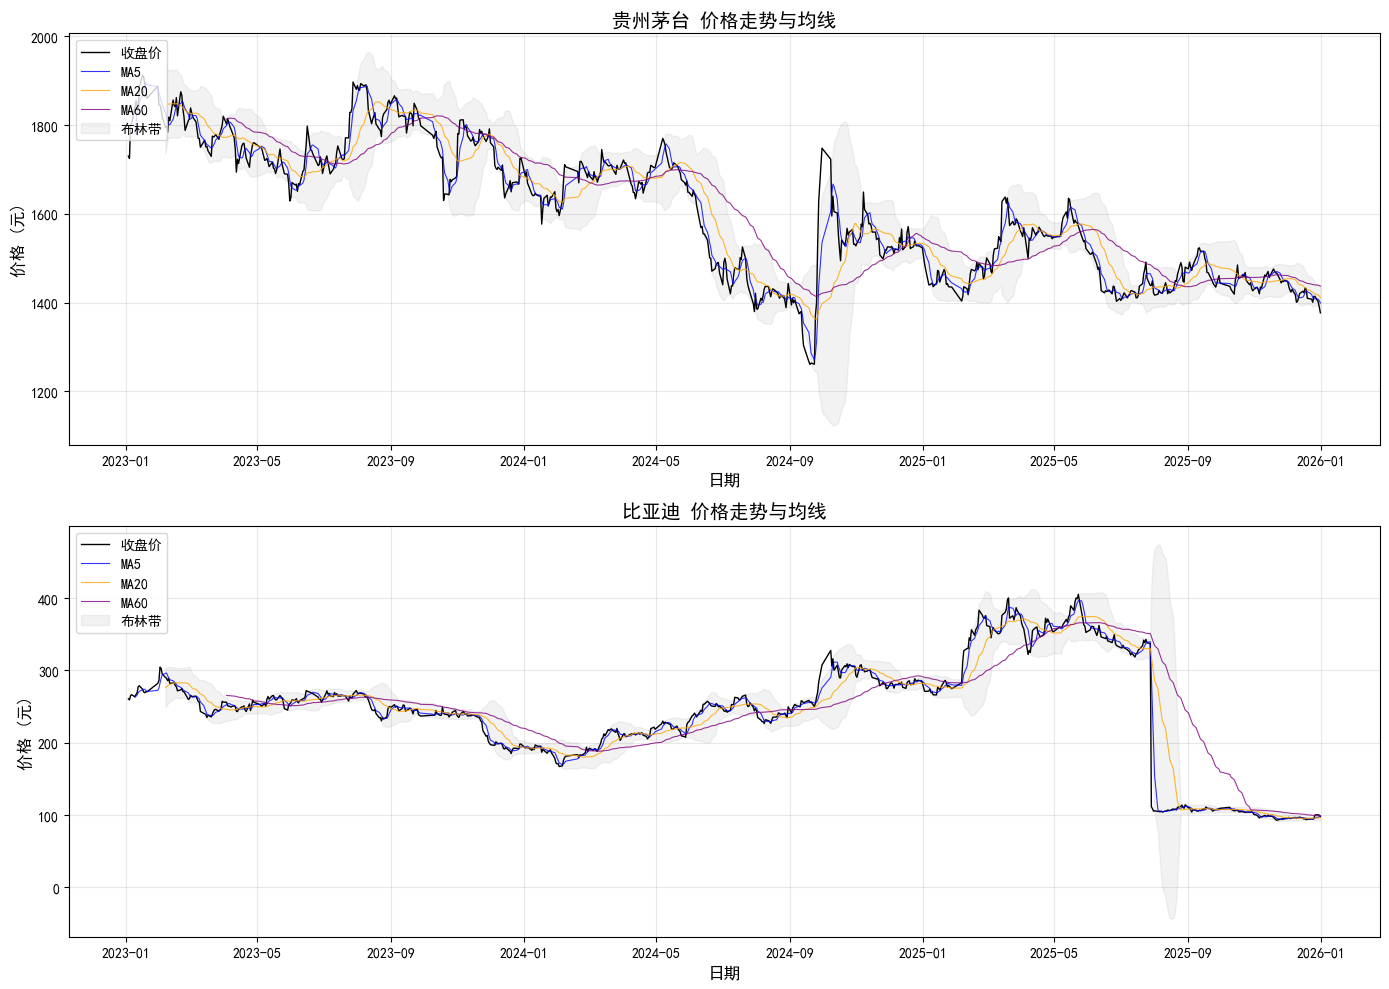

图片已保存: 题目一_output/rice_trend_with_ma.png


In [15]:
# 绘制价格走势图（含均线）
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 贵州茅台
ax1 = axes[0]
ax1.plot(df_maotai_final.index, df_maotai_final['close'], label='收盘价', color='black', linewidth=1)
ax1.plot(df_maotai_final.index, df_maotai_final['MA5'], label='MA5', color='blue', linewidth=0.8, alpha=0.8)
ax1.plot(df_maotai_final.index, df_maotai_final['MA20'], label='MA20', color='orange', linewidth=0.8, alpha=0.8)
ax1.plot(df_maotai_final.index, df_maotai_final['MA60'], label='MA60', color='purple', linewidth=0.8, alpha=0.8)
ax1.fill_between(df_maotai_final.index, df_maotai_final['BOLL_UP'], df_maotai_final['BOLL_DOWN'], 
                  alpha=0.1, color='gray', label='布林带')
ax1.set_xlabel('日期', fontsize=12)
ax1.set_ylabel('价格 (元)', fontsize=12)
ax1.set_title('贵州茅台 价格走势与均线', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 比亚迪
ax2 = axes[1]
ax2.plot(df_byd_final.index, df_byd_final['close'], label='收盘价', color='black', linewidth=1)
ax2.plot(df_byd_final.index, df_byd_final['MA5'], label='MA5', color='blue', linewidth=0.8, alpha=0.8)
ax2.plot(df_byd_final.index, df_byd_final['MA20'], label='MA20', color='orange', linewidth=0.8, alpha=0.8)
ax2.plot(df_byd_final.index, df_byd_final['MA60'], label='MA60', color='purple', linewidth=0.8, alpha=0.8)
ax2.fill_between(df_byd_final.index, df_byd_final['BOLL_UP'], df_byd_final['BOLL_DOWN'], 
                  alpha=0.1, color='gray', label='布林带')
ax2.set_xlabel('日期', fontsize=12)
ax2.set_ylabel('价格 (元)', fontsize=12)
ax2.set_title('比亚迪 价格走势与均线', fontsize=14)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('题目一_output/price_trend_with_ma.png', dpi=150, bbox_inches='tight')
plt.show()

print("图片已保存: 题目一_output/rice_trend_with_ma.png")

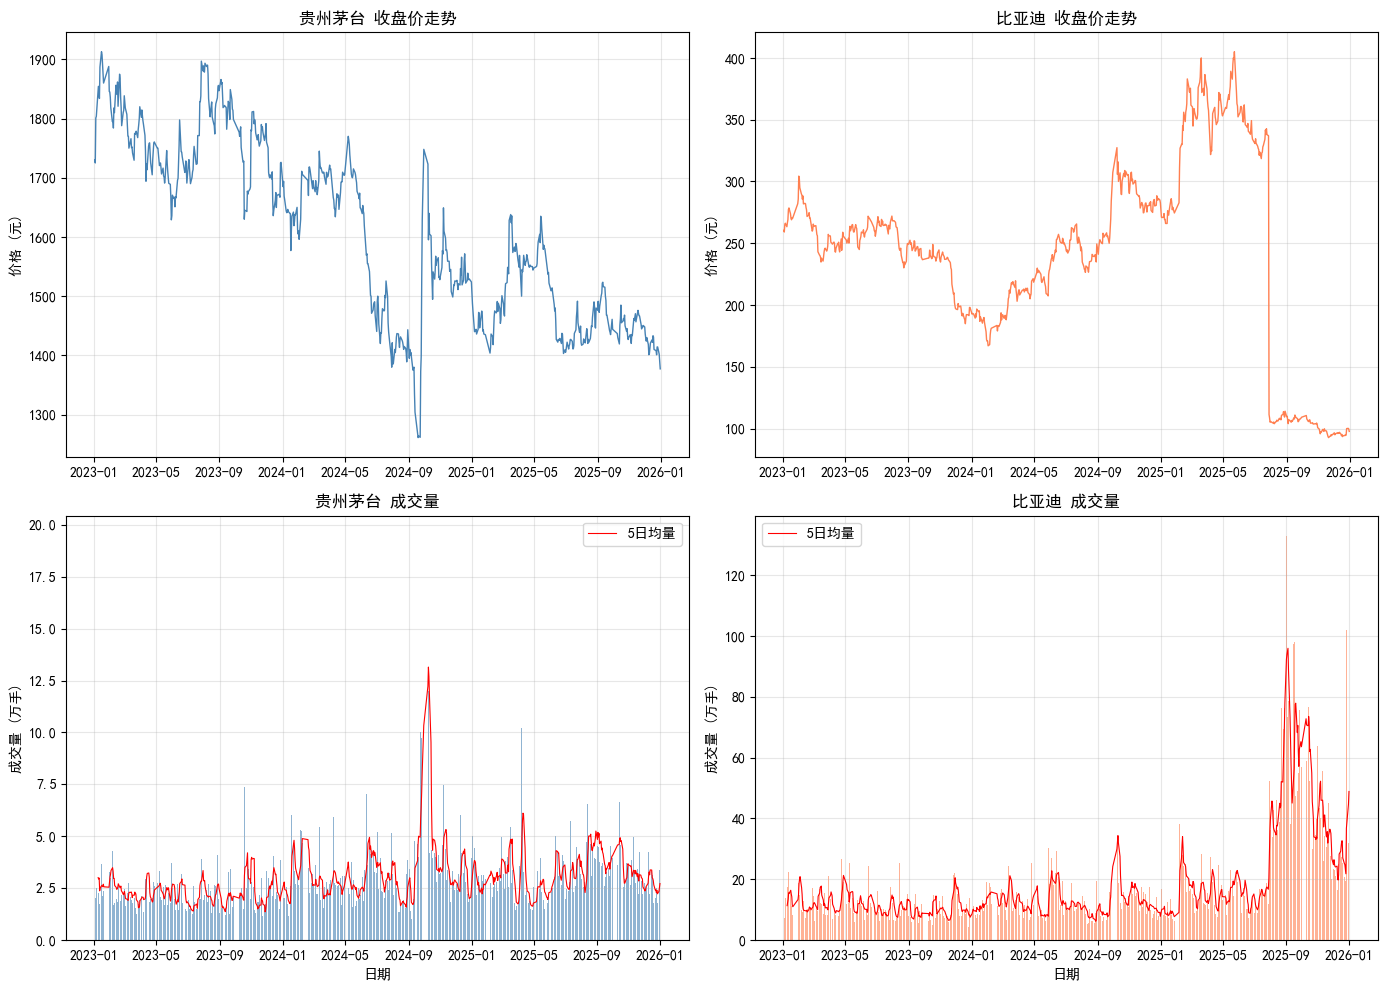

图片已保存: 题目一_output/price_volume_chart.png


In [16]:
# 绘制成交量与价格组合图
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 贵州茅台 - 价格
ax1 = axes[0, 0]
ax1.plot(df_maotai_final.index, df_maotai_final['close'], color='steelblue', linewidth=1)
ax1.set_ylabel('价格 (元)', fontsize=10)
ax1.set_title('贵州茅台 收盘价走势', fontsize=12)
ax1.grid(True, alpha=0.3)

# 贵州茅台 - 成交量
ax2 = axes[1, 0]
ax2.bar(df_maotai_final.index, df_maotai_final['volume']/10000, color='steelblue', alpha=0.6, width=1)
ax2.plot(df_maotai_final.index, df_maotai_final['volume_MA5']/10000, color='red', linewidth=0.8, label='5日均量')
ax2.set_xlabel('日期', fontsize=10)
ax2.set_ylabel('成交量 (万手)', fontsize=10)
ax2.set_title('贵州茅台 成交量', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 比亚迪 - 价格
ax3 = axes[0, 1]
ax3.plot(df_byd_final.index, df_byd_final['close'], color='coral', linewidth=1)
ax3.set_ylabel('价格 (元)', fontsize=10)
ax3.set_title('比亚迪 收盘价走势', fontsize=12)
ax3.grid(True, alpha=0.3)

# 比亚迪 - 成交量
ax4 = axes[1, 1]
ax4.bar(df_byd_final.index, df_byd_final['volume']/10000, color='coral', alpha=0.6, width=1)
ax4.plot(df_byd_final.index, df_byd_final['volume_MA5']/10000, color='red', linewidth=0.8, label='5日均量')
ax4.set_xlabel('日期', fontsize=10)
ax4.set_ylabel('成交量 (万手)', fontsize=10)
ax4.set_title('比亚迪 成交量', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('题目一_output/price_volume_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("图片已保存: 题目一_output/price_volume_chart.png")

### 2.3.5 累计收益率对比

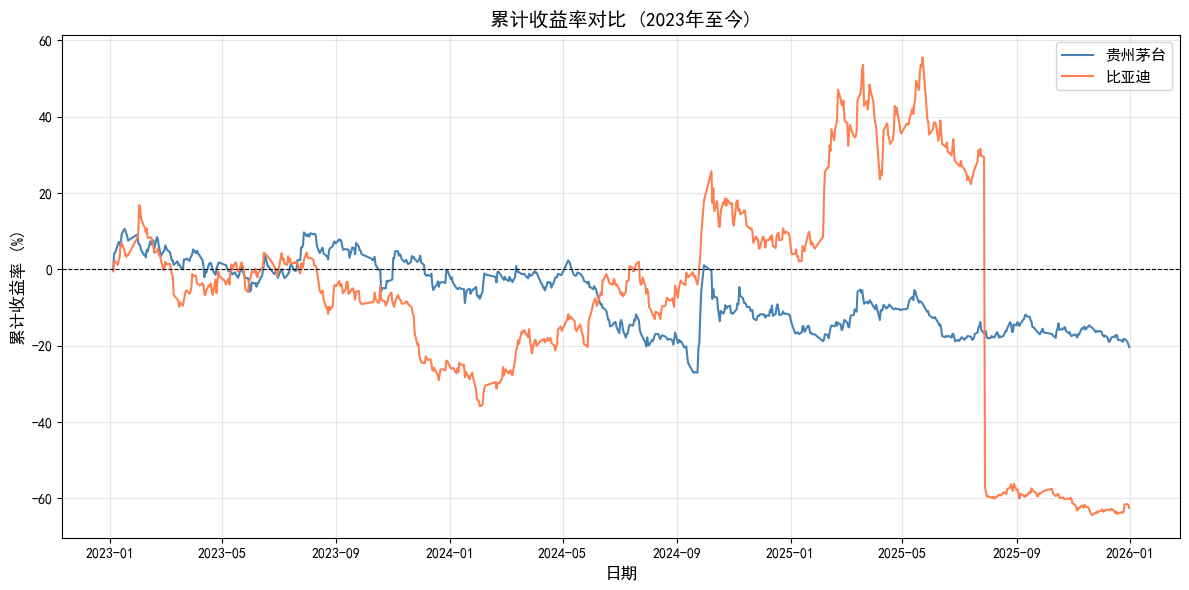

图片已保存: 题目一_output/cumulative_return.png


In [17]:
# 绘制累计收益率对比图
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_maotai_final.index, df_maotai_final['cum_return'], 
        label='贵州茅台', color='steelblue', linewidth=1.5)
ax.plot(df_byd_final.index, df_byd_final['cum_return'], 
        label='比亚迪', color='coral', linewidth=1.5)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

ax.set_xlabel('日期', fontsize=12)
ax.set_ylabel('累计收益率 (%)', fontsize=12)
ax.set_title('累计收益率对比 (2023年至今)', fontsize=14)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('题目一_output/cumulative_return.png', dpi=150, bbox_inches='tight')
plt.show()

print("图片已保存: 题目一_output/cumulative_return.png")

### 2.3.6 RSI指标分析

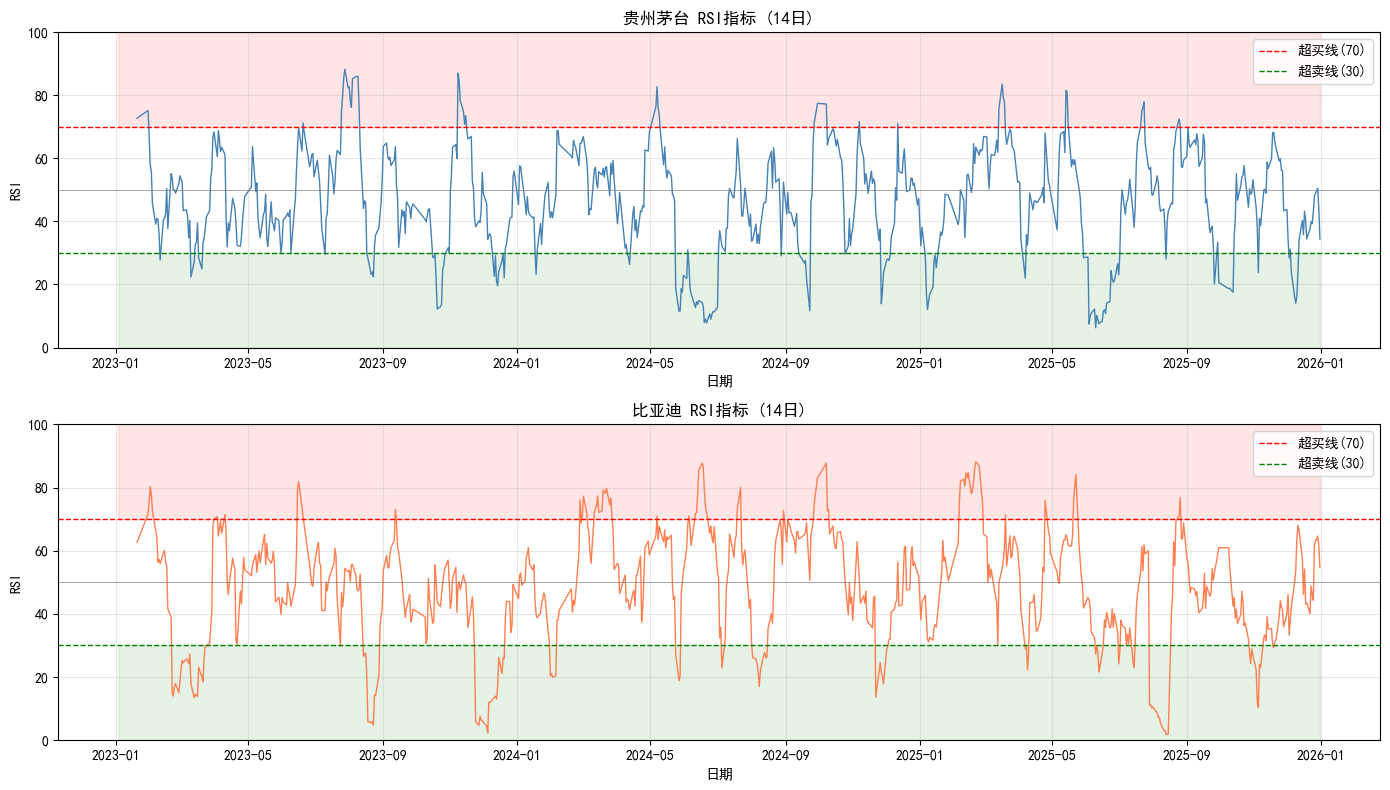

图片已保存: 题目一_output/rsi_chart.png


In [18]:
# 绘制RSI指标图
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 贵州茅台
ax1 = axes[0]
ax1.plot(df_maotai_final.index, df_maotai_final['RSI'], color='steelblue', linewidth=1)
ax1.axhline(70, color='red', linestyle='--', linewidth=1, label='超买线(70)')
ax1.axhline(30, color='green', linestyle='--', linewidth=1, label='超卖线(30)')
ax1.axhline(50, color='gray', linestyle='-', linewidth=0.5)
ax1.fill_between(df_maotai_final.index, 70, 100, alpha=0.1, color='red')
ax1.fill_between(df_maotai_final.index, 0, 30, alpha=0.1, color='green')
ax1.set_xlabel('日期', fontsize=10)
ax1.set_ylabel('RSI', fontsize=10)
ax1.set_title('贵州茅台 RSI指标 (14日)', fontsize=12)
ax1.set_ylim(0, 100)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# 比亚迪
ax2 = axes[1]
ax2.plot(df_byd_final.index, df_byd_final['RSI'], color='coral', linewidth=1)
ax2.axhline(70, color='red', linestyle='--', linewidth=1, label='超买线(70)')
ax2.axhline(30, color='green', linestyle='--', linewidth=1, label='超卖线(30)')
ax2.axhline(50, color='gray', linestyle='-', linewidth=0.5)
ax2.fill_between(df_byd_final.index, 70, 100, alpha=0.1, color='red')
ax2.fill_between(df_byd_final.index, 0, 30, alpha=0.1, color='green')
ax2.set_xlabel('日期', fontsize=10)
ax2.set_ylabel('RSI', fontsize=10)
ax2.set_title('比亚迪 RSI指标 (14日)', fontsize=12)
ax2.set_ylim(0, 100)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('题目一_output/rsi_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("图片已保存: 题目一_output/rsi_chart.png")

### 2.3.7 波动率分析

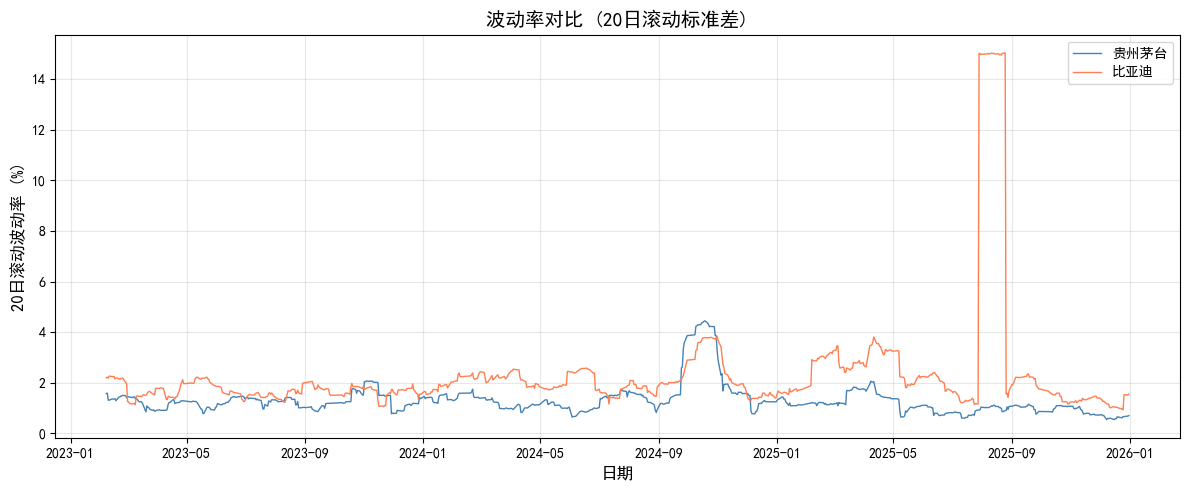

图片已保存: 题目一_output/volatility_chart.png


In [19]:
# 绘制波动率对比图
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_maotai_final.index, df_maotai_final['volatility_20'], 
        label='贵州茅台', color='steelblue', linewidth=1)
ax.plot(df_byd_final.index, df_byd_final['volatility_20'], 
        label='比亚迪', color='coral', linewidth=1)

ax.set_xlabel('日期', fontsize=12)
ax.set_ylabel('20日滚动波动率 (%)', fontsize=12)
ax.set_title('波动率对比 (20日滚动标准差)', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('题目一_output/volatility_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("图片已保存: 题目一_output/volatility_chart.png")

### 2.3.8 相关性分析

In [20]:
# 计算两只股票收益率的相关性
# 首先对齐两个DataFrame的索引
common_index = df_maotai_final.index.intersection(df_byd_final.index)

returns_df = pd.DataFrame({
    '贵州茅台': df_maotai_final.loc[common_index, 'daily_return'],
    '比亚迪': df_byd_final.loc[common_index, 'daily_return']
}).dropna()

# 计算相关系数
correlation = returns_df.corr()
print("日收益率相关系数矩阵：")
print(correlation)
print(f"\n相关系数: {correlation.iloc[0, 1]:.4f}")

日收益率相关系数矩阵：
          贵州茅台       比亚迪
贵州茅台  1.000000  0.276766
比亚迪   0.276766  1.000000

相关系数: 0.2768


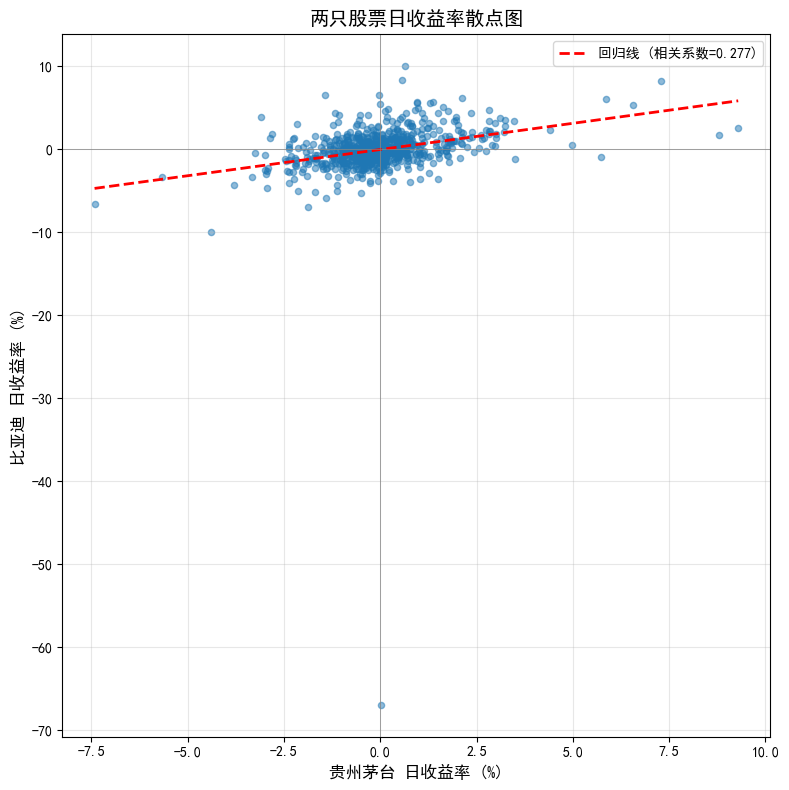

图片已保存: 题目一_output/correlation_scatter.png


In [21]:
# 绘制散点图
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(returns_df['贵州茅台'], returns_df['比亚迪'], alpha=0.5, s=20)

# 添加回归线
z = np.polyfit(returns_df['贵州茅台'], returns_df['比亚迪'], 1)
p = np.poly1d(z)
x_line = np.linspace(returns_df['贵州茅台'].min(), returns_df['贵州茅台'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'回归线 (相关系数={correlation.iloc[0,1]:.3f})')

ax.axhline(0, color='gray', linestyle='-', linewidth=0.5)
ax.axvline(0, color='gray', linestyle='-', linewidth=0.5)
ax.set_xlabel('贵州茅台 日收益率 (%)', fontsize=12)
ax.set_ylabel('比亚迪 日收益率 (%)', fontsize=12)
ax.set_title('两只股票日收益率散点图', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('题目一_output/correlation_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("图片已保存: 题目一_output/correlation_scatter.png")

## 2.4 数据保存

In [22]:
# 保存处理后的数据到CSV文件
df_maotai_final.to_csv('maotai_processed.csv', encoding='utf-8-sig')
df_byd_final.to_csv('byd_processed.csv', encoding='utf-8-sig')

print("数据已保存！")
print("  - maotai_processed.csv")
print("  - byd_processed.csv")

数据已保存！
  - maotai_processed.csv
  - byd_processed.csv


## 2.5 小结

本部分完成了以下工作：

**1. 数据获取**
- 使用akshare模块获取了贵州茅台（600519）和比亚迪（002594）两只股票2023年至今的日频数据
- 数据包含开盘价、收盘价、最高价、最低价、成交量、换手率等字段

**2. 数据清洗**
- 将日期列转换为时间戳格式并设为索引
- 检查并处理缺失值和重复值
- 重命名列名为英文，便于后续处理

**3. 技术指标计算**
- 移动平均线：MA5、MA10、MA20、MA60
- 收益率指标：日收益率、对数收益率、累计收益率
- 波动率指标：20日滚动标准差
- 其他指标：RSI(14)、布林带

**4. 数据初步分析**
- 描述性统计分析
- 日收益率分布分析
- 成交量分布分析
- 价格走势与均线可视化
- 累计收益率对比
- 波动率分析
- 两只股票的相关性分析